# Customer Churn Prediction

# Business Understanding

# Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Code to create kaggle path for data download
# Code taken from stackoverflow user fdsig
import json
import os
from pathlib import Path

# your api key
api_key = {
'username':"",
'key':""}

# uses pathlib Path
kaggle_path = Path('/root/.kaggle')
os.makedirs(kaggle_path, exist_ok=True)

# opens file and dumps python dict to json object
with open (kaggle_path/'kaggle.json', 'w') as handl:
    json.dump(api_key,handl)

os.chmod(kaggle_path/'kaggle.json', 600)

In [3]:
# Downloading kaggle dataset
# Cell output cleared as only contains data download progress
!kaggle datasets download -d muhammadshahidazeem/customer-churn-dataset

# Creating parent folder directory for data unzip
!unzip customer-churn-dataset.zip -d customer-churn-dataset

Dataset URL: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset
License(s): GPL-2.0
100% 6.66M/6.66M [00:02<00:00, 3.20MB/s]

Archive:  customer-churn-dataset.zip
  inflating: customer-churn-dataset/customer_churn_dataset-testing-master.csv  
  inflating: customer-churn-dataset/customer_churn_dataset-training-master.csv  


In [4]:
data = pd.read_csv('/content/customer-churn-dataset/customer_churn_dataset-training-master.csv')

In [5]:
data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [7]:
data.isna().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


## Data Preprocessing

In [9]:
# Lowercasing and replacing whitespace in columns
data.columns = data.columns.str.lower().str.replace(' ', '_')
data.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [11]:
# Dropping single NaN row
data = data.dropna()
data[data['customerid'].isna()]

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn


In [14]:
# Converting non-monetary numbers to integer dtype
col_list = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']

for col in col_list:
  data[col] = data[col].astype('int64')

In [15]:
data

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,2.0,30,Female,39,14,5,18,Standard,Annual,932.00,17,1
1,3.0,65,Female,49,1,10,8,Basic,Monthly,557.00,6,1
2,4.0,55,Female,14,4,6,18,Basic,Quarterly,185.00,3,1
3,5.0,58,Male,38,21,7,7,Standard,Monthly,396.00,29,1
4,6.0,23,Male,32,20,5,8,Basic,Monthly,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
440829,449996.0,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
440830,449997.0,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
440831,449998.0,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


## Exploratory data Analysis

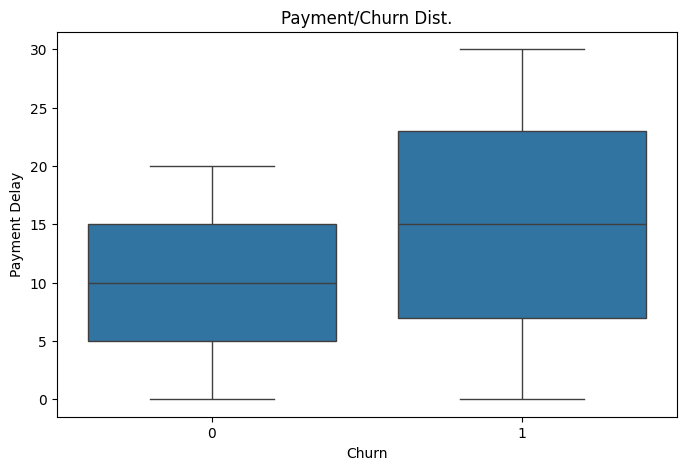

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data, x= data['churn'], y= data['payment_delay'])

ax.set_title('Payment/Churn Dist.')
ax.set_xlabel('Churn')
ax.set_ylabel('Payment Delay');

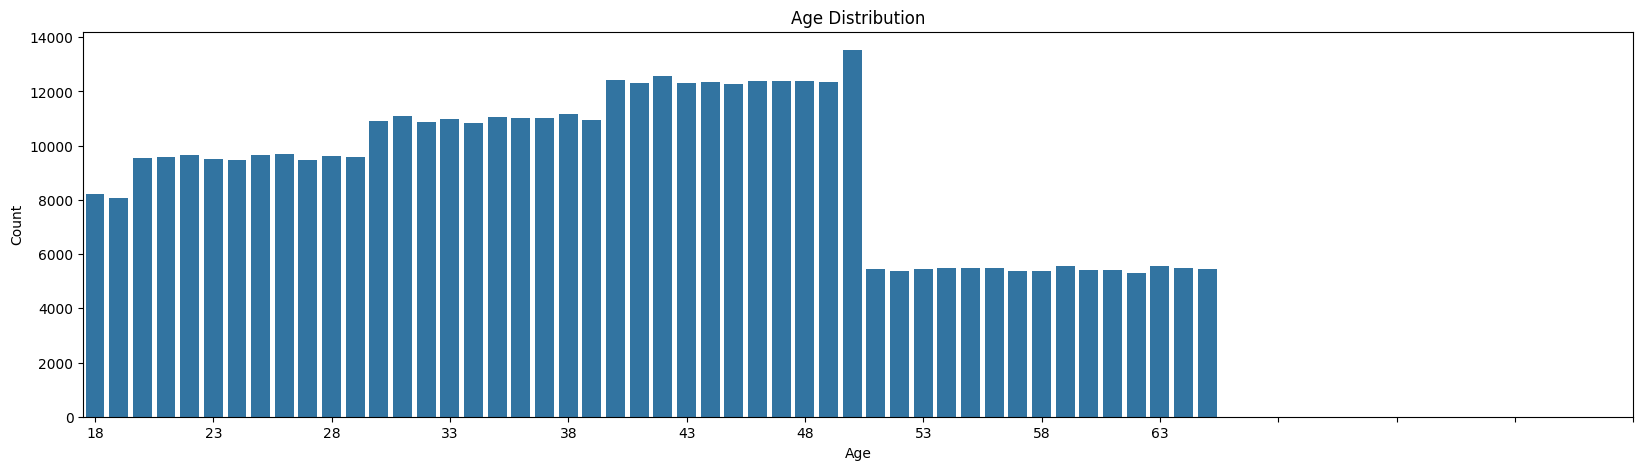

In [19]:
age_dict_vc = dict(data['age'].value_counts())
age_values = list(age_dict_vc.values())
age_keys = list(age_dict_vc.keys())

fig, ax = plt.subplots(figsize=(20, 5))

sns.barplot(x=age_keys, y=age_values)

ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_xticks(np.arange(0, 66, 5))
ax.set_ylabel('Count');

# Data Preparation

# Modeling

# Evaluation

## Limitations

## Next Steps

# Conclusion